In [ ]:
# Upload kaggle.json
from google.colab import files
files.upload()

In [ ]:
!kaggle datasets download -d olistbr/brazilian-ecommerce
!unzip -q brazilian-ecommerce.zip

print("Dataset downloaded!")

In [ ]:
import os
print(os.getcwd())
print(os.listdir())

/content
['.config', 'olist_geolocation_dataset.csv', 'product_category_name_translation.csv', 'olist_products_dataset.csv', 'survivor_vs_onehit.png', 'olist_order_items_dataset.csv', 'kaggle (1).json', 'flywheel_effect.png', 'kaggle.json', 'olist_order_payments_dataset.csv', 'olist_customers_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_orders_dataset.csv', 'olist_sellers_dataset.csv', 'brazilian-ecommerce.zip', 'one_hit_wonder_by_category.png', 'sample_data']


# Imports & Load

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

orders = pd.read_csv('/content/olist_orders_dataset.csv')
order_items = pd.read_csv('/content/olist_order_items_dataset.csv')
reviews = pd.read_csv('/content/olist_order_reviews_dataset.csv')
products = pd.read_csv('/content/olist_products_dataset.csv')
category_translation = pd.read_csv('/content/product_category_name_translation.csv')

print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Reviews:", reviews.shape)
print("Products:", products.shape)

Orders: (99441, 8)
Order Items: (112650, 7)
Reviews: (99224, 7)
Products: (32951, 9)


# **Build product_stats (single clean merge)**

In [ ]:
# Reviews are at order level — merge with order_items first,
# then aggregate to product level in one shot.
# Bringing price in here too so we never have duplicate column issues later.

items_reviews = order_items.merge(
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='left'
)

product_stats = items_reviews.groupby('product_id').agg(
    total_orders=('order_id', 'count'),
    avg_review_score=('review_score', 'mean'),
    review_count=('review_score', 'count'),
    score_std=('review_score', 'std'),
    avg_price=('price', 'mean')
).reset_index()

product_stats['score_std'] = product_stats['score_std'].fillna(0)

print(product_stats.shape)
product_stats.describe()

(32951, 6)


,total_orders,avg_review_score,review_count,score_std,avg_price
count,32951.000000,32789.000000,32951.000000,32951.000000,32951.000000
mean,3.438864,4.047807,3.410276,0.404291,145.303216
std,10.686685,1.213910,10.605462,0.702821,246.895887
min,1.000000,1.000000,0.000000,0.000000,0.850000
25%,1.000000,3.611111,1.000000,0.000000,39.900000
50%,1.000000,4.500000,1.000000,0.000000,79.000000
75%,3.000000,5.000000,3.000000,0.707107,154.900000
max,527.000000,5.000000,524.000000,2.828427,6735.000000


# Segmentation

In [ ]:
boring_mask = (
    (product_stats['total_orders'] <= product_stats['total_orders'].quantile(0.33)) &
    (product_stats['review_count'] <= product_stats['review_count'].quantile(0.33)) &
    (product_stats['score_std'] <= product_stats['score_std'].quantile(0.33))
)

exciting_mask = (
    (product_stats['total_orders'] >= product_stats['total_orders'].quantile(0.67)) &
    (product_stats['review_count'] >= product_stats['review_count'].quantile(0.67)) &
    (product_stats['score_std'] >= product_stats['score_std'].quantile(0.67))
)

product_stats['segment'] = 'middle'
product_stats.loc[boring_mask, 'segment'] = 'boring'
product_stats.loc[exciting_mask, 'segment'] = 'exciting'

product_stats['one_hit_wonder'] = product_stats['total_orders'] == 1

print(product_stats['segment'].value_counts())
print("\nOne-hit wonders:", product_stats['one_hit_wonder'].sum())

segment
boring      18012
exciting    14840
middle         99
Name: count, dtype: int64

One-hit wonders: 18012


# Merge with categories (single merge, no duplicates)

In [ ]:
products_translated = products.merge(
    category_translation,
    on='product_category_name',
    how='left'
)

# One single merge — all info in one place
product_full = product_stats.merge(
    products_translated[['product_id', 'product_category_name_english']],
    on='product_id',
    how='left'
)

print(product_full.columns.tolist())
print(product_full.shape)

['product_id', 'total_orders', 'avg_review_score', 'review_count', 'score_std', 'avg_price', 'segment', 'one_hit_wonder', 'product_category_name_english']
(32951, 9)


# Category analysis

In [ ]:
category_analysis = product_full.groupby('product_category_name_english').agg(
    total_products=('product_id', 'count'),
    one_hit_wonders=('one_hit_wonder', 'sum'),
    avg_orders=('total_orders', 'mean')
).reset_index()

category_analysis['one_hit_pct'] = (
    category_analysis['one_hit_wonders'] / category_analysis['total_products'] * 100
).round(1)

category_analysis = category_analysis[category_analysis['total_products'] >= 50]
category_analysis = category_analysis.sort_values('one_hit_pct', ascending=False)

print(category_analysis[['product_category_name_english',
                           'total_products',
                           'one_hit_wonders',
                           'one_hit_pct',
                           'avg_orders']].head(15).to_string(index=False))

product_category_name_english  total_products  one_hit_wonders  one_hit_pct  avg_orders
        fashion_male_clothing              95               81         85.3    1.389474
                fashion_shoes             173              130         75.1    1.531792
                          art              55               39         70.9    3.800000
           christmas_supplies              65               44         67.7    2.353846
                         auto            1900             1267         66.7    2.240000
              books_technical             123               81         65.9    2.186992
     fashion_bags_accessories             849              553         65.1    2.414605
              home_appliances             370              234         63.2    2.186486
   agro_industry_and_commerce              74               46         62.2    2.864865
    construction_tools_safety              91               56         61.5    2.131868
      fashion_underwear_beach   

# Chart 1: One-hit wonder by category

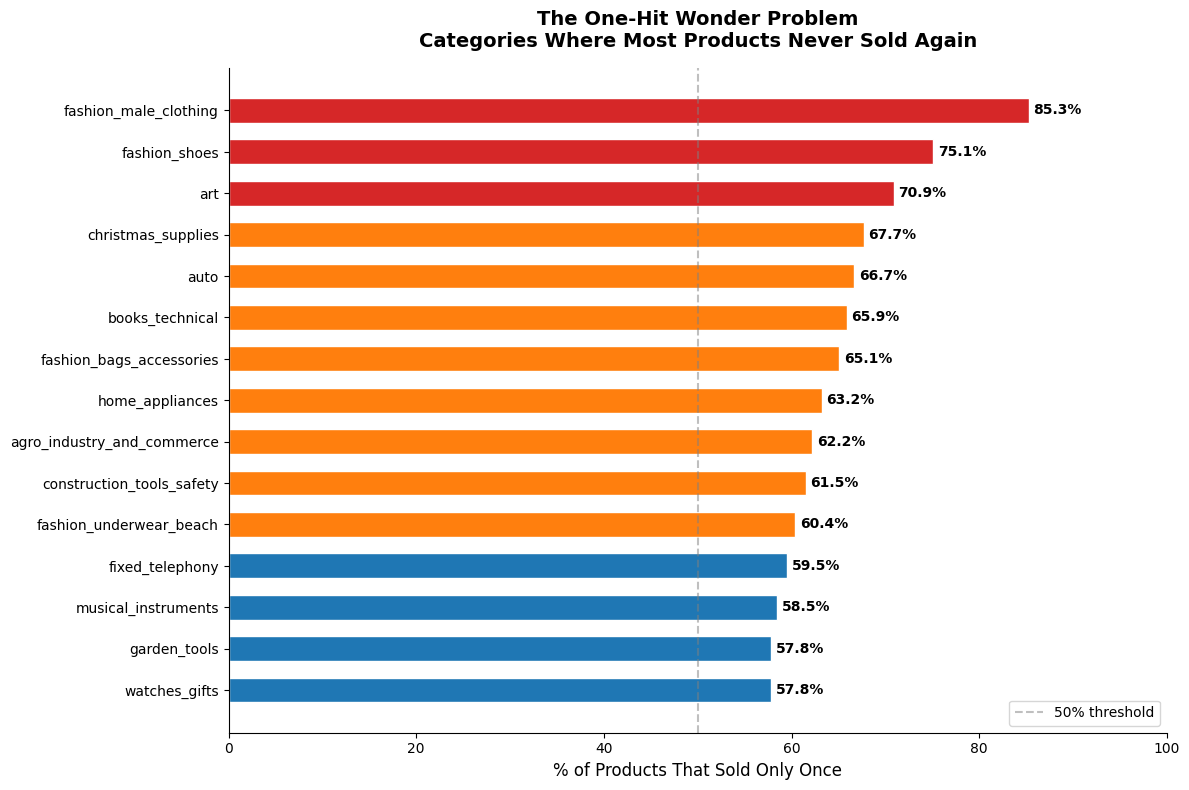

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#d62728' if x >= 70 else '#ff7f0e' if x >= 60 else '#1f77b4'
          for x in category_analysis['one_hit_pct'].head(15)]

bars = ax.barh(
    category_analysis['product_category_name_english'].head(15),
    category_analysis['one_hit_pct'].head(15),
    color=colors,
    edgecolor='white',
    height=0.6
)

for bar, val in zip(bars, category_analysis['one_hit_pct'].head(15)):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('% of Products That Sold Only Once', fontsize=12)
ax.set_title('The One-Hit Wonder Problem\nCategories Where Most Products Never Sold Again',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, 100)
ax.axvline(x=50, color='gray', linestyle='--', alpha=0.5, label='50% threshold')
ax.legend(fontsize=10)
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('one_hit_wonder_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

# Survivor vs One-Hit Wonder comparison

In [ ]:
comparison = product_full.groupby('one_hit_wonder').agg(
    avg_price=('avg_price', 'mean'),
    median_price=('avg_price', 'median'),
    avg_review_score=('avg_review_score', 'mean'),
    product_count=('product_id', 'count')
).reset_index()

comparison['one_hit_wonder'] = comparison['one_hit_wonder'].map(
    {True: 'One-Hit Wonder', False: 'Survivor'}
)

print(comparison.to_string(index=False))

one_hit_wonder  avg_price  median_price  avg_review_score  product_count
      Survivor 125.802189          72.9          4.027445          14939
One-Hit Wonder 161.477203          84.0          4.064812          18012


# Chart 2: Price and review score comparison

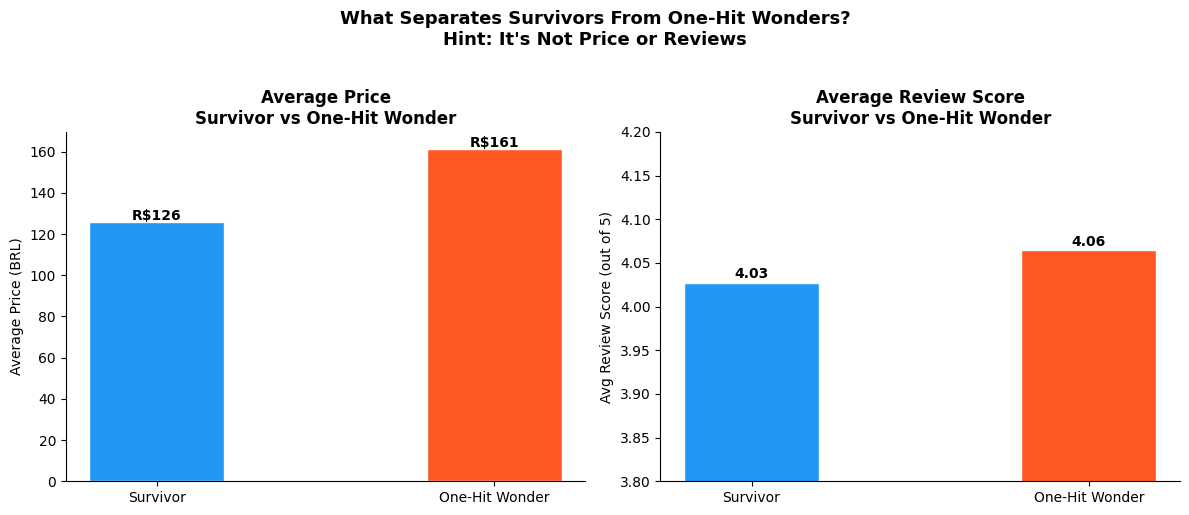

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#2196F3', '#FF5722']

axes[0].bar(comparison['one_hit_wonder'], comparison['avg_price'],
            color=colors, width=0.4, edgecolor='white')
axes[0].set_title('Average Price\nSurvivor vs One-Hit Wonder', fontweight='bold')
axes[0].set_ylabel('Average Price (BRL)')
for i, val in enumerate(comparison['avg_price']):
    axes[0].text(i, val + 1, f'R${val:.0f}', ha='center', fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].bar(comparison['one_hit_wonder'], comparison['avg_review_score'],
            color=colors, width=0.4, edgecolor='white')
axes[1].set_title('Average Review Score\nSurvivor vs One-Hit Wonder', fontweight='bold')
axes[1].set_ylabel('Avg Review Score (out of 5)')
axes[1].set_ylim(3.8, 4.2)
for i, val in enumerate(comparison['avg_review_score']):
    axes[1].text(i, val + 0.005, f'{val:.2f}', ha='center', fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle("What Separates Survivors From One-Hit Wonders?\nHint: It's Not Price or Reviews",
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('survivor_vs_onehit.png', dpi=150, bbox_inches='tight')
plt.show()

# The Flywheel Effect (order volume over time)

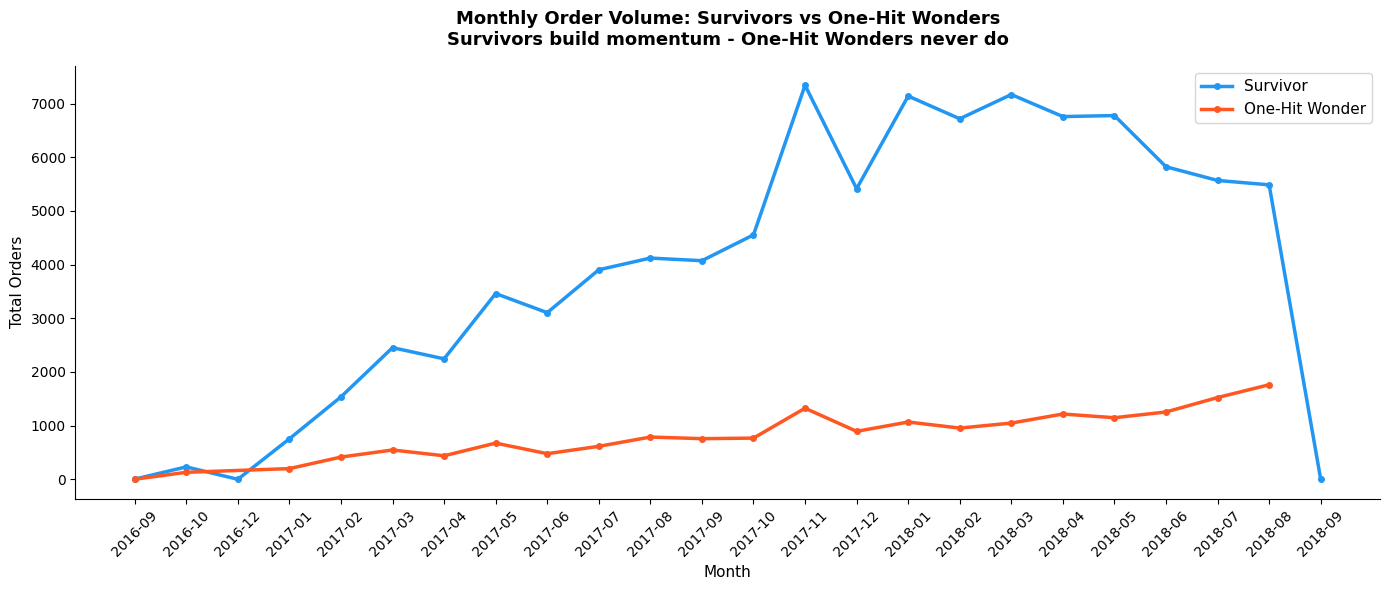

In [ ]:
# The hypothesis now is that survivors built momentum over time —
# early orders led to more visibility, which led to more orders.
# One-hit wonders never got that flywheel started.
# To show this, let's look at how orders accumulate month by month
# for survivors vs one-hit wonders.

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['year_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

# Merge order_items with segment info and order dates
order_timeline = order_items.merge(
    product_full[['product_id', 'one_hit_wonder']],
    on='product_id',
    how='left'
).merge(
    orders[['order_id', 'year_month']],
    on='order_id',
    how='left'
)

# Monthly order volume by segment
monthly_orders = order_timeline.groupby(
    ['year_month', 'one_hit_wonder']
).size().reset_index(name='order_count')

monthly_orders['year_month'] = monthly_orders['year_month'].astype(str)
monthly_orders['segment'] = monthly_orders['one_hit_wonder'].map(
    {True: 'One-Hit Wonder', False: 'Survivor'}
)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

for segment, color in [('Survivor', '#2196F3'), ('One-Hit Wonder', '#FF5722')]:
    data = monthly_orders[monthly_orders['segment'] == segment]
    ax.plot(data['year_month'], data['order_count'],
            label=segment, color=color, linewidth=2.5, marker='o', markersize=4)

ax.set_title('Monthly Order Volume: Survivors vs One-Hit Wonders\nSurvivors build momentum - One-Hit Wonders never do',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Total Orders', fontsize=11)
ax.legend(fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('flywheel_effect.png', dpi=150, bbox_inches='tight')
plt.show()